## Maestría en Inteligencia Artificial Aplicada

### Curso: Inteligencia Artificial y Aprendizaje Automático

**Tecnológico de Monterrey**

Prof. Luis Eduardo Falcón Morales

Actividad de Semana 3 — Rotación de Personal (IBM)

### Presenta

Carlos Rodrigo Salguero Alcántara

A00833341


## 1.0 Introducción — rotación de personal

La rotación de personal (*employee attrition*) ocurre cuando alguien deja la empresa — de forma voluntaria o no — y hay que cubrir ese lugar. Tiene costo real: reclutar y capacitar, bajar el ritmo del equipo y, a veces, perder conocimiento que no está documentado. En esta actividad uso aprendizaje automático para estimar quién tiene más riesgo de irse, con la idea de que RH pueda intervenir a tiempo (y de forma ética).

## 2.0 Configuración del notebook

### 2.1 Importaciones

In [90]:
from __future__ import annotations


In [91]:
from dataclasses import dataclass
from pathlib import Path
from typing import Final, Literal, TypeAlias

In [92]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [93]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    PowerTransformer,
)

### 2.2 Constantes, tipos y estilo de gráficos

In [94]:
ArrayLike: TypeAlias = np.ndarray | pd.Series | pd.DataFrame
AttritionLabel: TypeAlias = Literal[0, 1]

In [95]:
RANDOM_STATE_SPLIT: Final[int] = 17
RANDOM_STATE_MODEL: Final[int] = 1
RANDOM_STATE_CV: Final[int] = 7
TRAIN_SIZE: Final[float] = 0.70
VAL_TEST_RATIO: Final[float] = 0.50
OVERFIT_GAP_MAX: Final[float] = 0.03
BASELINE_ACCURACY: Final[float] = 0.839

In [96]:
DATA_PATH: Final[Path] = Path("data") / "WA_Fn-UseC_-HR-Employee-Attrition.csv"
TARGET_COL: Final[str] = "Attrition"

In [97]:
PLOT_PRIMARY: Final[str] = "#2F6F8F"
PLOT_SECONDARY: Final[str] = "#C46B3A"
PLOT_ACCENT: Final[str] = "#3D8B6E"
PLOT_BASELINE: Final[str] = "#B3261E"
PLOT_CMAP: Final[str] = "Blues"
PLOT_EDGE: Final[str] = "white"
PLOT_PALETTE: Final[list[str]] = [PLOT_PRIMARY, PLOT_SECONDARY]

In [98]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)

In [99]:
def style_axes(
    ax: plt.Axes,
    title: str,
    xlabel: str = "",
    ylabel: str = "",
) -> plt.Axes:
    ax.set_title(title, pad=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    return ax

In [100]:
def finalize_figure() -> None:
    plt.tight_layout()
    plt.show()

In [101]:
def attrition_rate(frame: pd.DataFrame, column: str) -> pd.Series:
    """
    Share of Attrition==Yes by category, sorted descending.
    """
    
    rates = (
        frame[TARGET_COL]
        .eq("Yes")
        .groupby(frame[column], observed=True)
        .mean()
        .sort_values(ascending=False)
    )

    rates.name = "attrition_rate"
    return rates

In [102]:
def plot_ranked_bars(
    series: pd.Series,
    title: str,
    xlabel: str,
    ylabel: str = "Count",
    color: str = PLOT_PRIMARY,
    figsize: tuple[float, float] = (10, 4),
    rotate: int = 0,
) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    series.plot(kind="bar", ax=ax, color=color, edgecolor=PLOT_EDGE)
    style_axes(ax, title, xlabel, ylabel)
    if rotate:
        plt.xticks(rotation=rotate, ha="right")
        
    finalize_figure()

### 2.3 Dataclasses de configuración

In [103]:
@dataclass(frozen=True, slots=True)
class SplitConfig:
    train_size: float = TRAIN_SIZE
    val_test_ratio: float = VAL_TEST_RATIO
    random_state: int = RANDOM_STATE_SPLIT
    stratify: bool = True

In [104]:
@dataclass(frozen=True, slots=True)
class CvConfig:
    n_splits: int = 5
    n_repeats: int = 3
    random_state: int = RANDOM_STATE_CV
    scoring: str = "accuracy"

In [105]:
SPLIT_CFG = SplitConfig()
CV_CFG = CvConfig()

## 3.0 Carga de datos

Dataset: [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset) (1,470 registros).

In [106]:
def load_attrition_data(path: Path = DATA_PATH) -> pd.DataFrame:
    """
    Load the CSV and fail early if the file is missing.
    """

    if not path.exists():
        raise FileNotFoundError(
            f"Missing file: {path.resolve()}. Place the CSV under data/."
        )

    return pd.read_csv(path)

In [107]:
data: pd.DataFrame = load_attrition_data()
print(f"DataFrame shape: {data.shape}")
print(f"Memory usage: {data.memory_usage(deep=True).sum() / 1_048_576:.2f} MB")

DataFrame shape: (1470, 35)
Memory usage: 1.02 MB


In [108]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.000,NaN,NaN,NaN,36.924,9.135,18.000,30.000,36.000,43.000,60.000
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.000,NaN,NaN,NaN,802.486,403.509,102.000,465.000,802.000,1157.000,1499.000
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.000,NaN,NaN,NaN,9.193,8.107,1.000,2.000,7.000,14.000,29.000
Education,1470.000,NaN,NaN,NaN,2.913,1.024,1.000,2.000,3.000,4.000,5.000
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.000,NaN,NaN,NaN,1.000,0.000,1.000,1.000,1.000,1.000,1.000
EmployeeNumber,1470.000,NaN,NaN,NaN,1024.865,602.024,1.000,491.250,1020.500,1555.750,2068.000


## 4.0 Ejercicio 2 — eliminar columnas no informativas

Antes de modelar, hay que quitar lo que no aporta: constantes (sin varianza) o identificadores únicos. El enunciado pide cuatro.

In [109]:
cardinality: pd.Series = data.nunique(dropna=False).sort_values()
n_rows: int = len(data)

In [110]:
diagnostics: pd.DataFrame = pd.DataFrame(
    {
        "n_unique": cardinality,
        "is_constant": cardinality.eq(1),
        "is_unique_id": cardinality.eq(n_rows),
        "pct_unique": cardinality / n_rows,
    }
)

display(diagnostics)

,n_unique,is_constant,is_unique_id,pct_unique
EmployeeCount,1,True,False,0.001
Over18,1,True,False,0.001
StandardHours,1,True,False,0.001
Attrition,2,False,False,0.001
OverTime,2,False,False,0.001
PerformanceRating,2,False,False,0.001
Gender,2,False,False,0.001
BusinessTravel,3,False,False,0.002
Department,3,False,False,0.002
MaritalStatus,3,False,False,0.002


In [111]:
COLS_TO_DROP: Final[list[str]] = [
    "EmployeeCount",  
    "Over18", 
    "StandardHours", 
    "EmployeeNumber",  
]

In [112]:
df: pd.DataFrame = data.drop(columns=COLS_TO_DROP).copy()
print(f"New DataFrame shape: {df.shape}")
assert TARGET_COL in df.columns, "Do not drop the target column"
assert df.shape == (1470, 31), f"Unexpected shape: {df.shape}" 

New DataFrame shape: (1470, 31)


### 4.1 Justificación (Ejercicio 2b)

Revisé `n_unique` y el patrón es claro: tres columnas son constantes y una es un ID. Las quito desde el inicio:

| Variable | Evidencia | Motivo |
|---|---|---|
| **EmployeeCount** | `n_unique = 1` (siempre 1) | Sin varianza; no discrimina nada. |
| **Over18** | `n_unique = 1` (siempre "Y") | Todos son mayores de edad; no aporta. |
| **StandardHours** | `n_unique = 1` (siempre 80) | La misma jornada en todos los registros. |
| **EmployeeNumber** | `n_unique = n_rows` | ID único; no generaliza y el modelo podría "memorizarlo". |

Dejarlas solo mete ruido (o una fuga rara por identidad). Después del drop, `df` queda en **(1470 × 31)**.

## 5.0 Ejercicio 3 — tipología de variables y ética

### Taxonomía de variables (según Kaggle, después del drop)

- **Numéricas [14]:** Age, DailyRate, DistanceFromHome, HourlyRate, MonthlyIncome, MonthlyRate, NumCompaniesWorked, PercentSalaryHike, TotalWorkingYears, TrainingTimesLastYear, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager
- **Ordinales [9]:** Education (5), EnvironmentSatisfaction (4), JobInvolvement (4), JobLevel (5), JobSatisfaction (4), PerformanceRating (2), RelationshipSatisfaction (4), StockOptionLevel (4), WorkLifeBalance (4)
- **Binarias [3]:** Attrition (salida), Gender, OverTime
- **Nominales [5]:** BusinessTravel (3), Department (3), EducationField (6), JobRole (9), MaritalStatus (3)

In [113]:
NUMERIC_FEATURES: Final[list[str]] = [
    "NumCompaniesWorked",
    "TrainingTimesLastYear",
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "HourlyRate",
    "MonthlyIncome",
    "MonthlyRate",
    "PercentSalaryHike",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
]

In [114]:
ORDINAL_FEATURES: Final[list[str]] = [
    "Education",
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance",
]

In [115]:
BINARY_FEATURES: Final[list[str]] = [
    "Gender",
    "OverTime",
]

In [116]:
NOMINAL_FEATURES: Final[list[str]] = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus",
]

In [117]:
FEATURE_GROUPS: Final[dict[str, list[str]]] = {
    "numeric": NUMERIC_FEATURES,
    "ordinal": ORDINAL_FEATURES,
    "binary": BINARY_FEATURES,
    "nominal": NOMINAL_FEATURES,
}

In [118]:
all_x: list[str] = [c for cols in FEATURE_GROUPS.values() for c in cols]
assert len(all_x) == len(set(all_x)), "Duplicate features across groups"

In [119]:
missing = set(all_x) - set(df.columns)
assert not missing, f"Missing columns in df: {missing}"

In [120]:
extra = (set(df.columns) - {TARGET_COL}) - set(all_x)
assert not extra, f"Unclassified columns in df: {extra}"

In [121]:
print({k: len(v) for k, v in FEATURE_GROUPS.items()}, "| total X features:", len(all_x))

{'numeric': 14, 'ordinal': 9, 'binary': 2, 'nominal': 5} | total X features: 30


### 5.1 Preocupaciones éticas y legales (Age, Gender, MaritalStatus)

Si Age, Gender o MaritalStatus salieran como factores "fuertes" para decidir sobre personas, el problema no es solo técnico:

1. **Discriminación:** Usar edad, género o estado civil para retención, ascensos o despidos puede cruzar líneas legales y de igualdad.
2. **Sesgo:** Si el histórico ya era inequitativo, el modelo lo puede aprender y repetir.
3. **Privacidad:** Datos demográficos piden cuidado (LFPDPPP en México, GDPR en la UE, etc.).
4. **Uso del score:** Sirve para ofrecer apoyo (carga, carrera, clima), no para etiquetar o castigar.
5. **Antes de actuar:** Revisar fairness, acotar el propósito y mantener a una persona en el loop.

## 6.0 Ejercicio 4 — otros enfoques analíticos

Además de clasificar Attrition en Yes/No, se me ocurren al menos dos caminos útiles:

1. **Supervivencia (time-to-event):** No solo *si* se van, sino *cuándo* (Cox / Kaplan–Meier, usando antigüedad como YearsAtCompany).
2. **Score de riesgo:** Un número continuo para priorizar a quién contacta RH, en vez de un corte duro Yes/No.
3. *(Extra)* **Clustering:** Agrupar perfiles por satisfacción, overtime y sueldo para políticas distintas por segmento.

## 7.0 Partición train / validation / test

Partición estratificada: **70% / 15% / 15%**, `random_state=17`.

In [122]:
X: pd.DataFrame = df.drop(columns=[TARGET_COL])
y: pd.DataFrame = df[[TARGET_COL]].copy()

In [123]:
Xtrain, Xtv, ytrain, ytv = train_test_split(
    X,
    y,
    train_size=SPLIT_CFG.train_size,
    stratify=y if SPLIT_CFG.stratify else None,
    random_state=SPLIT_CFG.random_state,
)

In [124]:
Xval, Xtest, yval, ytest = train_test_split(
    Xtv,
    ytv,
    test_size=SPLIT_CFG.val_test_ratio,
    stratify=ytv if SPLIT_CFG.stratify else None,
    random_state=SPLIT_CFG.random_state,
)

In [125]:
def format_pct(n: int, total: int) -> str:
    return f"{100.0 * n / total:.1f}%"

In [126]:
split_summary = pd.DataFrame(
    {
        "rows": [Xtrain.shape[0], Xval.shape[0], Xtest.shape[0]],
        "pct": [
            format_pct(Xtrain.shape[0], X.shape[0]),
            format_pct(Xval.shape[0], X.shape[0]),
            format_pct(Xtest.shape[0], X.shape[0]),
        ],
        "n_features": [Xtrain.shape[1], Xval.shape[1], Xtest.shape[1]],
    },
    index=["Train", "Val", "Test"],
)

display(split_summary)

,rows,pct,n_features
Train,1029,70.0%,30
Val,220,15.0%,30
Test,221,15.0%,30


## 8.0 Ejercicio 5 — LabelEncoder en Attrition (sin leakage)

Ajustar el encoder **solo en train**; transformar validation y test.

In [127]:
label_encoder = LabelEncoder()


In [128]:
ytrainT = ytrain.copy()
yvalT = yval.copy()
ytestT = ytest.copy()

In [129]:
ytrainT[TARGET_COL] = label_encoder.fit_transform(ytrain[TARGET_COL])
yvalT[TARGET_COL] = label_encoder.transform(yval[TARGET_COL])
ytestT[TARGET_COL] = label_encoder.transform(ytest[TARGET_COL])

In [130]:
class_balance = ytrainT[TARGET_COL].value_counts(normalize=True).rename("train_share")
print("Encoder classes (index -> label):", list(enumerate(label_encoder.classes_)))
class_balance

Encoder classes (index -> label): [(0, 'No'), (1, 'Yes')]


Attrition
0   0.839
1   0.161
Name: train_share, dtype: float64

### 8.1 Respuestas (Ejercicio 5b–e)

**b)** Sklearn recomienda `LabelEncoder` para la variable objetivo en clasificación.  
Para features en `X`, mejor `OrdinalEncoder` / `OneHotEncoder` dentro de un `ColumnTransformer` o `Pipeline`.

**c)** Con el orden alfabético de LabelEncoder:
- `0` → **No** (se queda)
- `1` → **Yes** (renuncia / hay attrition)  
Lo confirmo con `label_encoder.classes_`.

**d)** El modelo ingenuo (“siempre predice la clase mayoritaria”) saca accuracy ≈ proporción de `No` en Train ≈ **0.839**.  
Eso es el piso: si no lo paso, el modelo no está haciendo nada útil en accuracy.

**e)** Sí, con ~84/16 el desbalance ya importa. Accuracy puede verse alta y aun así fallar en detectar a quienes se van.  
Me fijaría más en **recall/precision/F1 de Yes**, balanced accuracy, ROC-AUC y, sobre todo, **PR-AUC**.

## 9.0 Ejercicio 6 — EDA para decidir transformaciones

El EDA lo hago **solo con Train** (Test no se toca).  
No es “ver gráficos por ver”: quiero decidir
- qué numéricas escalar o transformar por sesgo,
- qué categóricas se relacionan con Attrition,
- y qué error duele más (FN vs FP) cuando llegue la evaluación.

Eso alimenta el `ColumnTransformer` del Ejercicio 7.

In [131]:
EDUCATION_LABELS: Final[dict[int, str]] = {
    1: "Below College",
    2: "College",
    3: "Bachelor",
    4: "Master",
    5: "Doctor",
}

In [132]:
eda_df: pd.DataFrame = Xtrain.assign(**{TARGET_COL: ytrain[TARGET_COL].to_numpy()})
attrition_yes: pd.DataFrame = eda_df.loc[eda_df[TARGET_COL].eq("Yes")]
attrition_no: pd.DataFrame = eda_df.loc[eda_df[TARGET_COL].eq("No")]

In [133]:
print(f"Train size: {len(eda_df)} | Yes: {len(attrition_yes)} | No: {len(attrition_no)}")
print("Train attrition rate: "
      f"{len(attrition_yes) / len(eda_df):.3f}")

Train size: 1029 | Yes: 166 | No: 863
Train attrition rate: 0.161


In [134]:
numeric_skew: pd.Series = (
    eda_df[NUMERIC_FEATURES].skew(numeric_only=True).sort_values(ascending=False)
)

print("Skew (train) — consider PowerTransformer when |skew| is high:")
numeric_skew.to_frame("skew")

Skew (train) — consider PowerTransformer when |skew| is high:


,skew
YearsSinceLastPromotion,2.040
YearsAtCompany,1.813
MonthlyIncome,1.394
TotalWorkingYears,1.158
NumCompaniesWorked,1.081
DistanceFromHome,0.890
YearsInCurrentRole,0.869
PercentSalaryHike,0.835
YearsWithCurrManager,0.750
TrainingTimesLastYear,0.510


### 9.0.1 Más análisis exploratorio (Train)

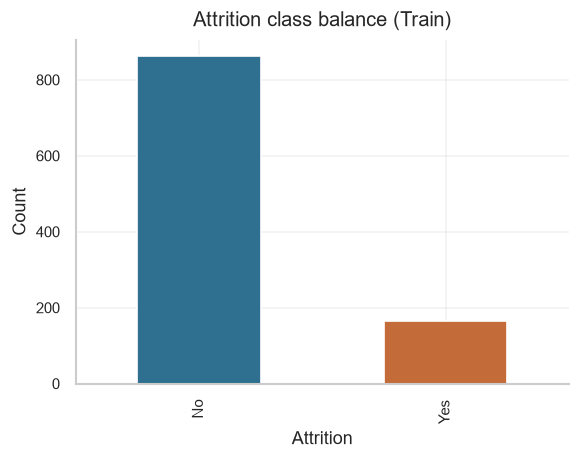

In [135]:
# Target balance
fig, ax = plt.subplots(figsize=(5, 4))
eda_df[TARGET_COL].value_counts().plot(
    kind="bar", ax=ax, color=PLOT_PALETTE, edgecolor=PLOT_EDGE
)

style_axes(ax, "Attrition class balance (Train)", TARGET_COL, "Count")
finalize_figure()

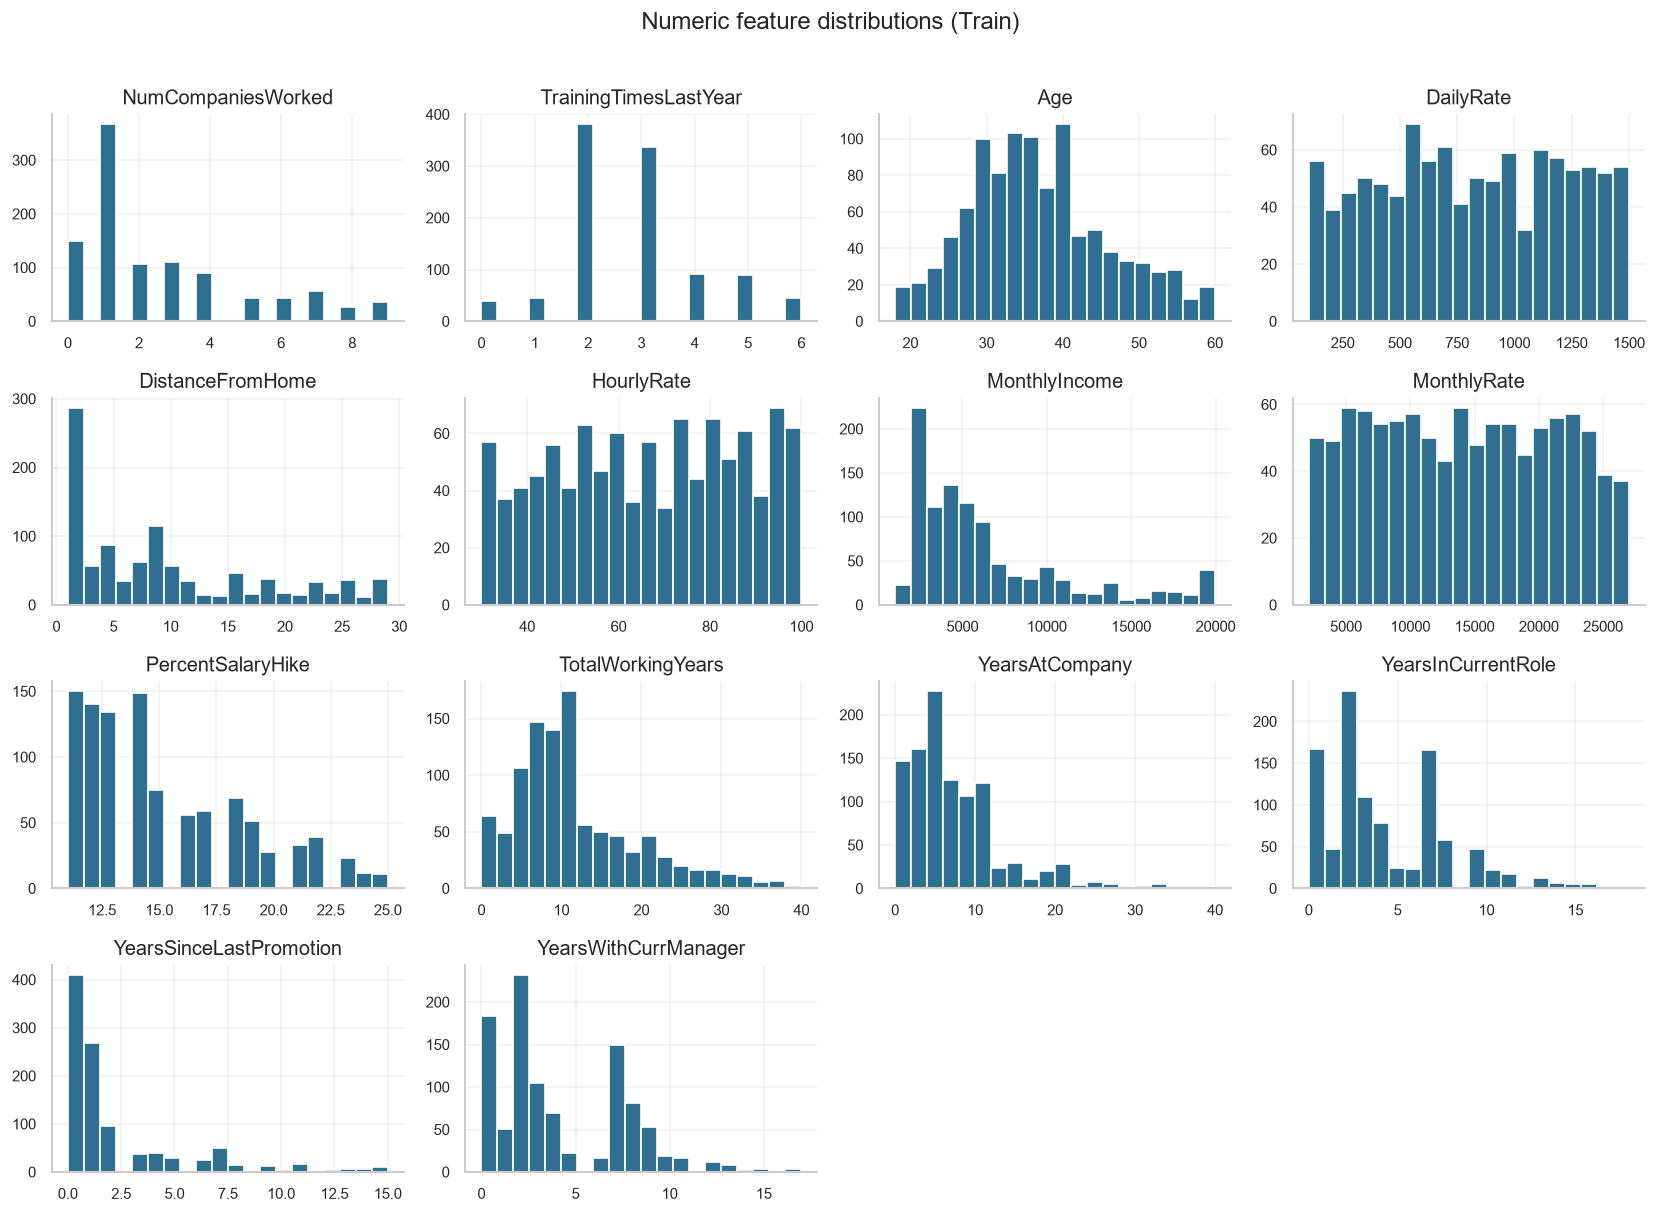

In [136]:
eda_df[NUMERIC_FEATURES].hist(
    figsize=(14, 10),
    bins=20,
    color=PLOT_PRIMARY,
    edgecolor=PLOT_EDGE,
)

plt.suptitle("Numeric feature distributions (Train)", y=1.01)
finalize_figure()

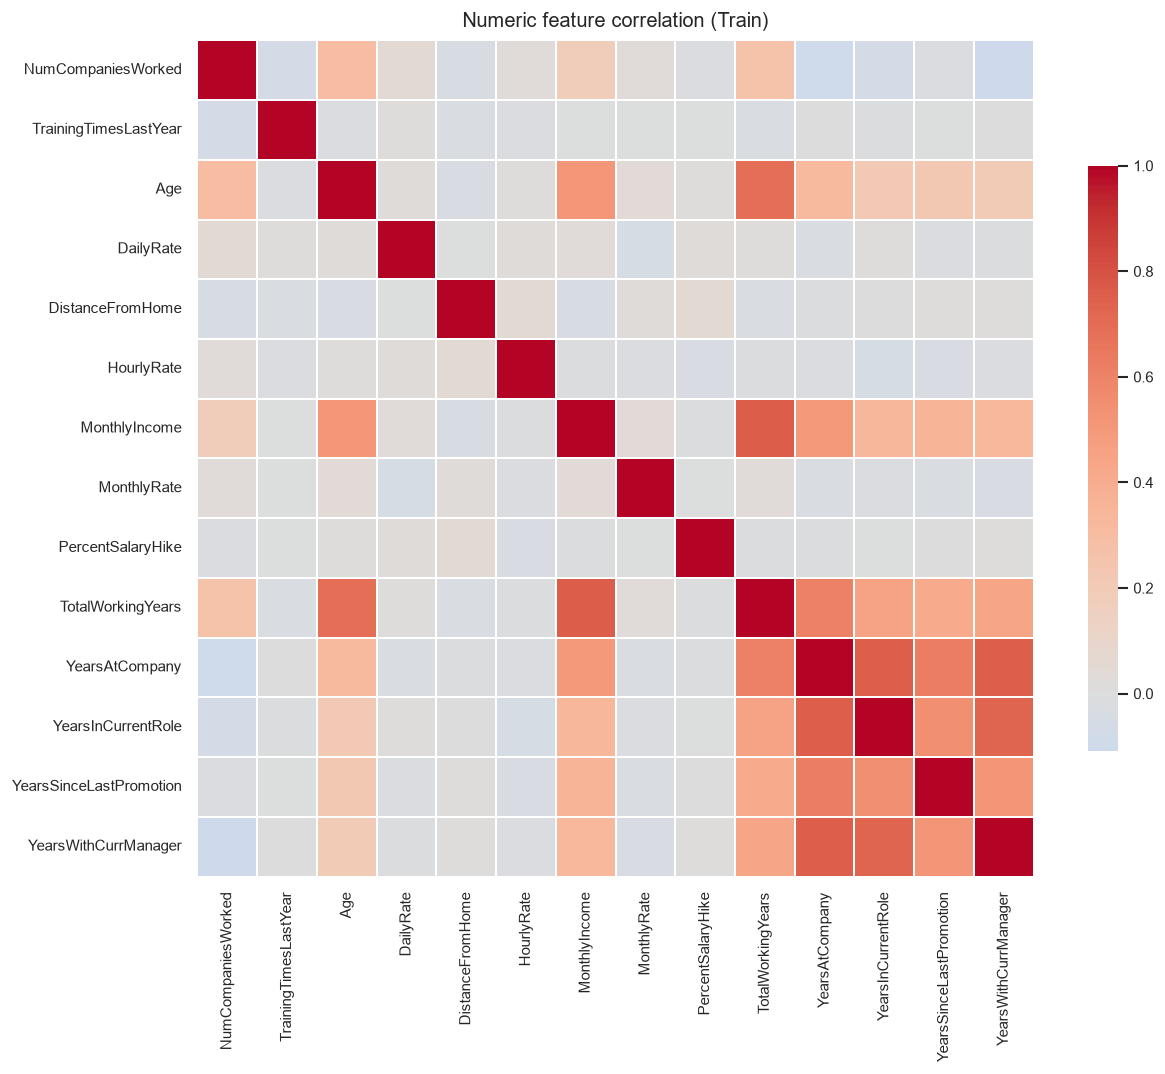

In [137]:
corr = eda_df[NUMERIC_FEATURES].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    corr,
    ax=ax,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.7},
)

style_axes(ax, "Numeric feature correlation (Train)")
finalize_figure()

In [138]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .abs()
    .sort_values(ascending=False)
    .head(12)
)

corr_pairs.to_frame()

corr
MonthlyIncome           TotalWorkingYears       0.765
YearsAtCompany          YearsWithCurrManager    0.757
                        YearsInCurrentRole      0.756
YearsInCurrentRole      YearsWithCurrManager    0.730
Age                     TotalWorkingYears       0.690
YearsAtCompany          YearsSinceLastPromotion 0.627
TotalWorkingYears       YearsAtCompany          0.613
YearsInCurrentRole      YearsSinceLastPromotion 0.549
YearsSinceLastPromotion YearsWithCurrManager    0.515
Age                     MonthlyIncome           0.510
MonthlyIncome           YearsAtCompany          0.495
TotalWorkingYears       YearsInCurrentRole      0.452

In [139]:
rate_cols = [
    "OverTime",
    "MaritalStatus",
    "JobRole",
    "BusinessTravel",
    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "WorkLifeBalance",
    "JobLevel",
]

rate_tables = {col: attrition_rate(eda_df, col) for col in rate_cols}
for col, rates in rate_tables.items():
    print(f"\n{col}:")
    print(rates.round(3))


OverTime:
OverTime
Yes   0.323
No    0.098
Name: attrition_rate, dtype: float64

MaritalStatus:
MaritalStatus
Single     0.268
Married    0.122
Divorced   0.093
Name: attrition_rate, dtype: float64

JobRole:
JobRole
Sales Representative        0.448
Human Resources             0.250
Laboratory Technician       0.213
Sales Executive             0.174
Research Scientist          0.163
Manufacturing Director      0.077
Healthcare Representative   0.071
Manager                     0.058
Research Director           0.018
Name: attrition_rate, dtype: float64

BusinessTravel:
BusinessTravel
Travel_Frequently   0.270
Travel_Rarely       0.141
Non-Travel          0.097
Name: attrition_rate, dtype: float64

JobSatisfaction:
JobSatisfaction
1   0.243
2   0.163
3   0.154
4   0.117
Name: attrition_rate, dtype: float64

EnvironmentSatisfaction:
EnvironmentSatisfaction
1   0.259
2   0.152
4   0.135
3   0.133
Name: attrition_rate, dtype: float64

WorkLifeBalance:
WorkLifeBalance
1   0.255
4   0.184
2

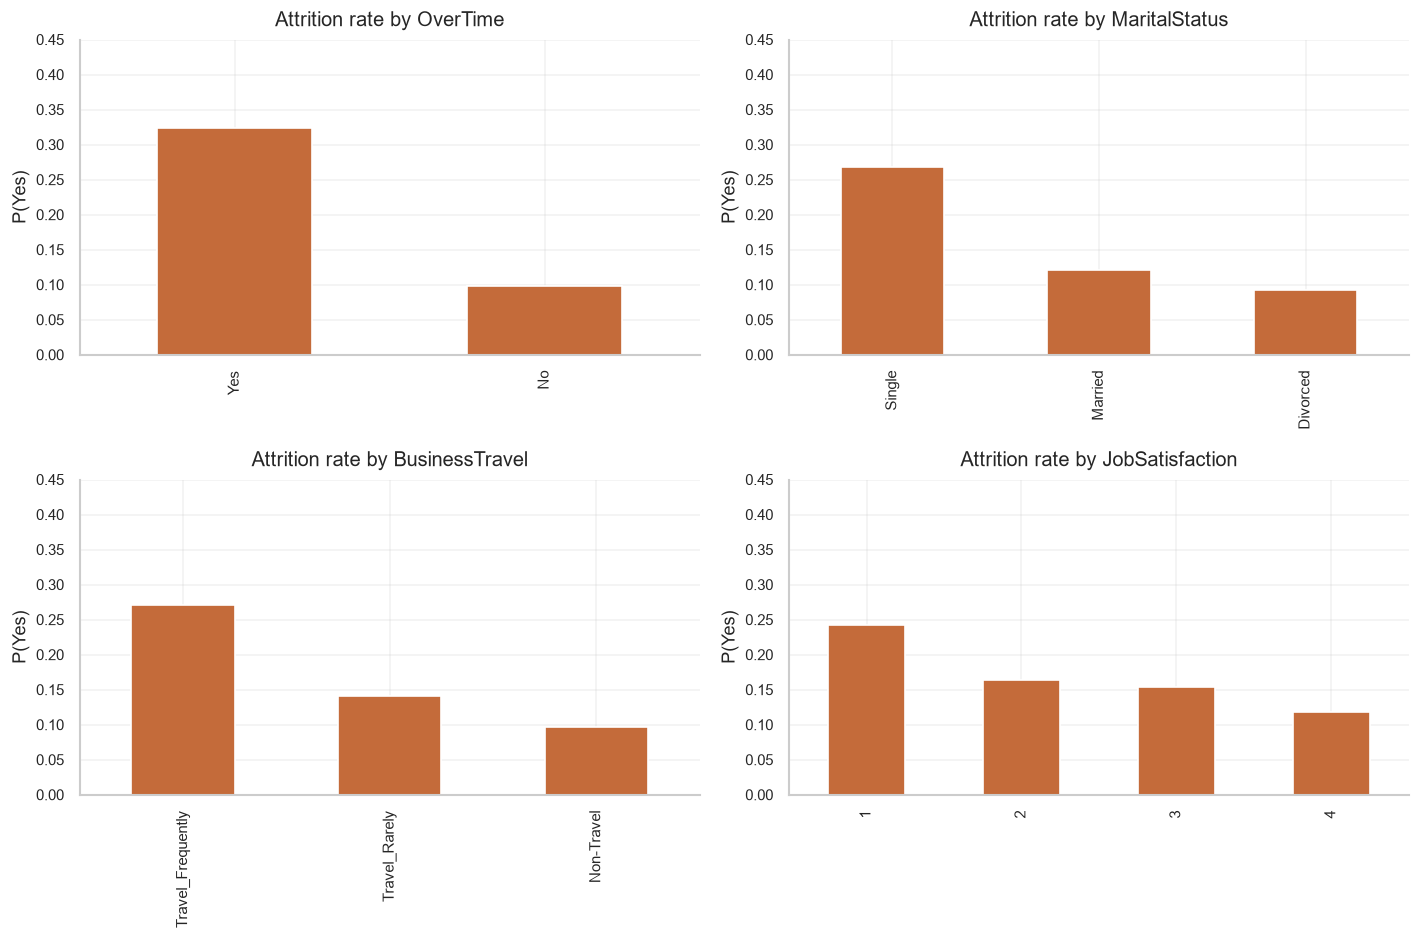

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(
    axes.ravel(),
    ["OverTime", "MaritalStatus", "BusinessTravel", "JobSatisfaction"],
    strict=True,
):
    rates = rate_tables[col]
    rates.plot(kind="bar", ax=ax, color=PLOT_SECONDARY, edgecolor=PLOT_EDGE)
    style_axes(ax, f"Attrition rate by {col}", ylabel="P(Yes)")
    ax.set_ylim(0, max(0.45, rates.max() * 1.15))
    
finalize_figure()

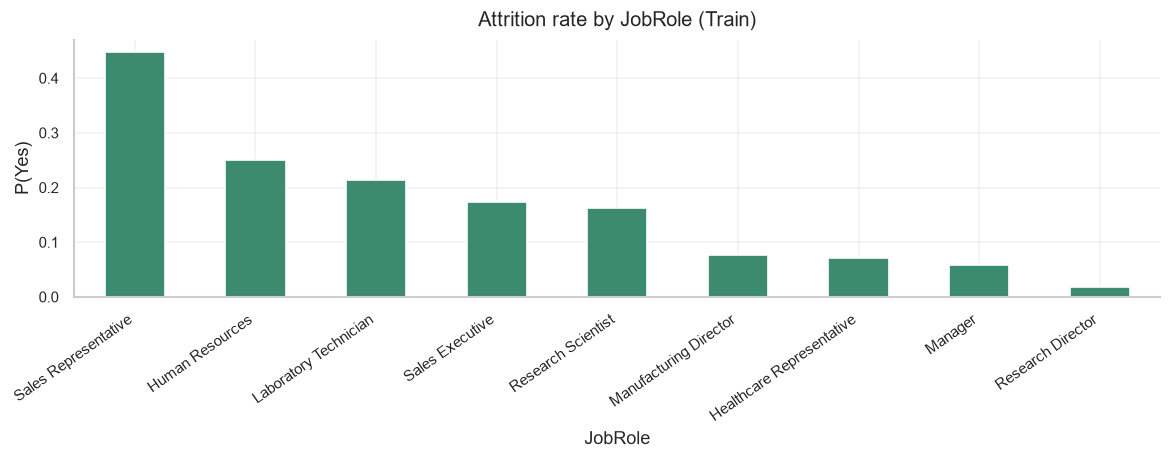

In [141]:
plot_ranked_bars(
    rate_tables["JobRole"],
    title="Attrition rate by JobRole (Train)",
    xlabel="JobRole",
    ylabel="P(Yes)",
    color=PLOT_ACCENT,
    figsize=(10, 4),
    rotate=35,
)

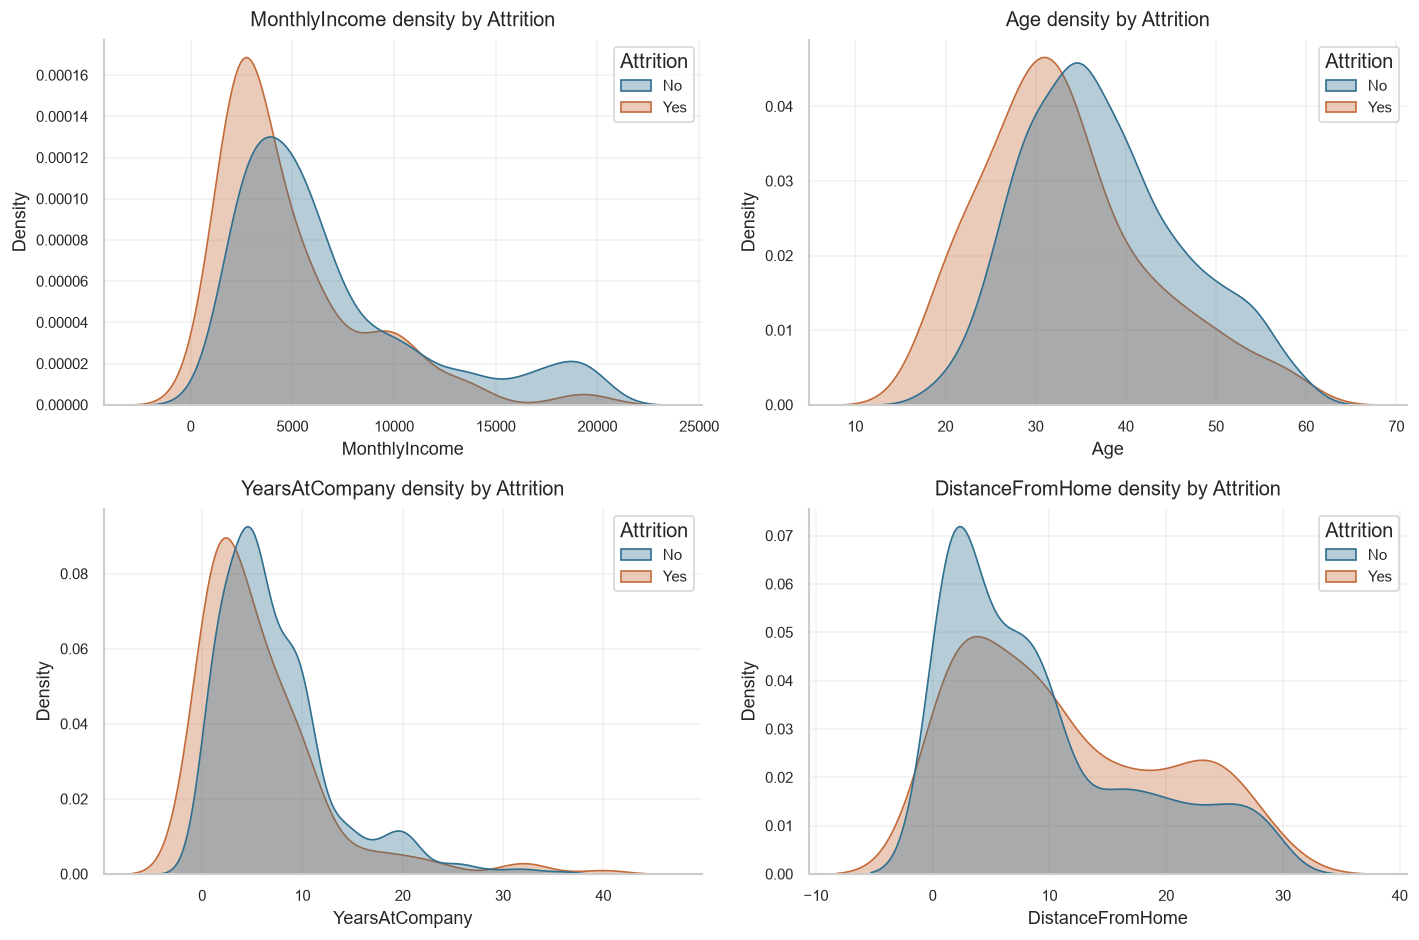

In [142]:
compare_cols = ["MonthlyIncome", "Age", "YearsAtCompany", "DistanceFromHome"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), compare_cols, strict=True):
    sns.kdeplot(
        data=eda_df,
        x=col,
        hue=TARGET_COL,
        ax=ax,
        fill=True,
        common_norm=False,
        palette=PLOT_PALETTE,
        alpha=0.35,
    )

    style_axes(ax, f"{col} density by Attrition", col, "Density")
    
finalize_figure()

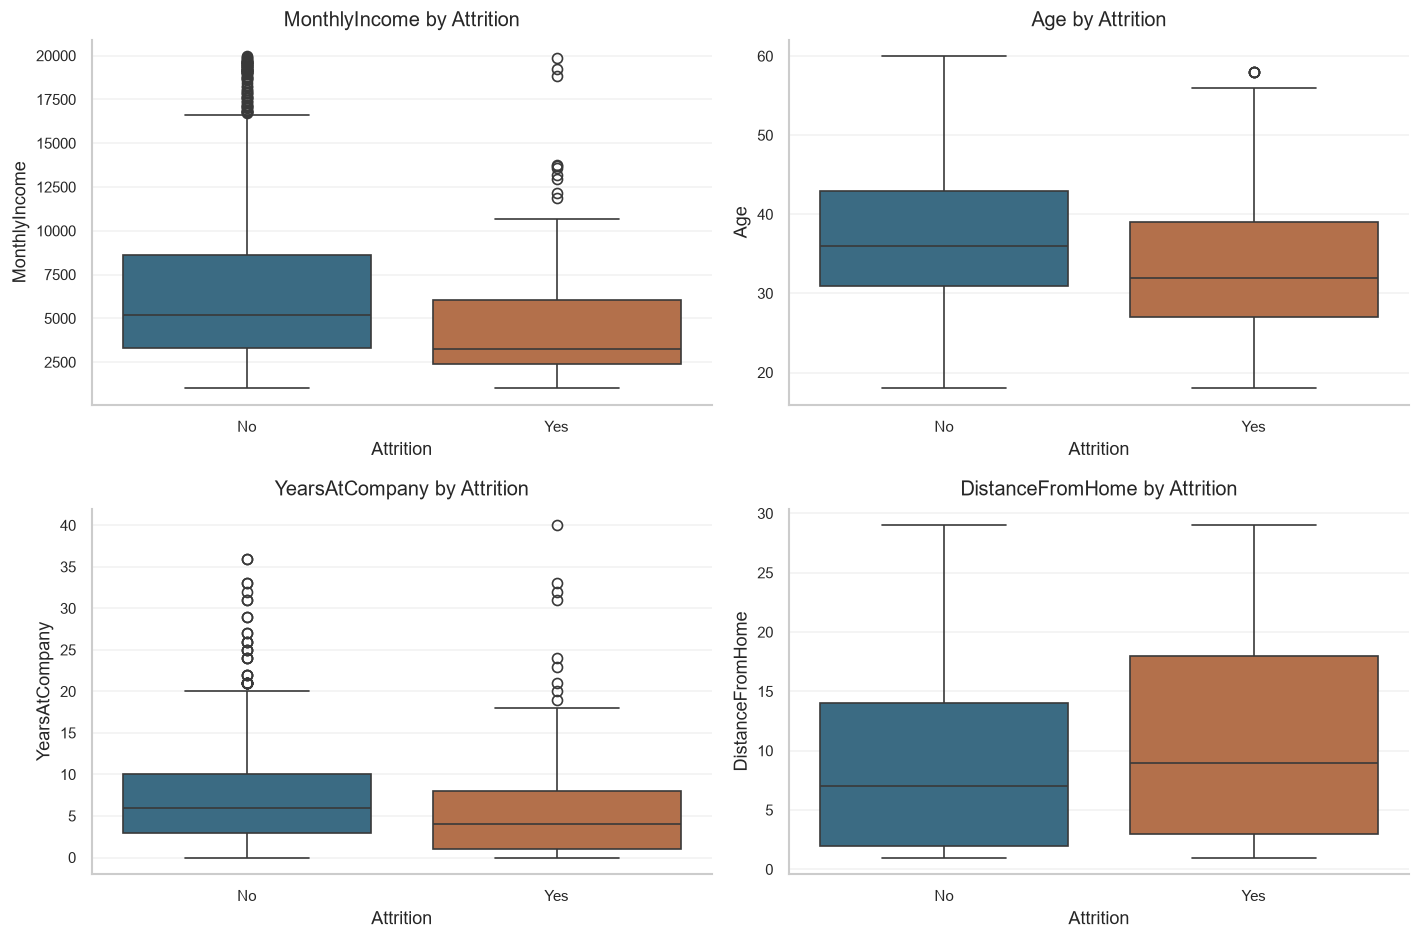

In [143]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), compare_cols, strict=True):
    sns.boxplot(
        data=eda_df,
        x=TARGET_COL,
        y=col,
        ax=ax,
        hue=TARGET_COL,
        palette=PLOT_PALETTE,
        legend=False,
    )

    style_axes(ax, f"{col} by Attrition", TARGET_COL, col)
    
finalize_figure()

In [144]:
profile = eda_df.groupby(TARGET_COL)[NUMERIC_FEATURES].mean().T
profile["diff_yes_minus_no"] = profile["Yes"] - profile["No"]
profile.sort_values("diff_yes_minus_no", key=lambda s: s.abs(), ascending=False).head(12)

Attrition,No,Yes,diff_yes_minus_no
MonthlyIncome,6834.920,4877.657,-1957.263
DailyRate,830.559,712.934,-117.625
MonthlyRate,14185.236,14223.223,37.987
Age,37.518,33.313,-4.205
TotalWorkingYears,11.702,8.759,-2.943
DistanceFromHome,9.183,11.096,1.913
YearsAtCompany,7.225,5.813,-1.412
YearsInCurrentRole,4.447,3.145,-1.303
YearsWithCurrManager,4.338,3.114,-1.224
NumCompaniesWorked,2.569,2.783,0.214


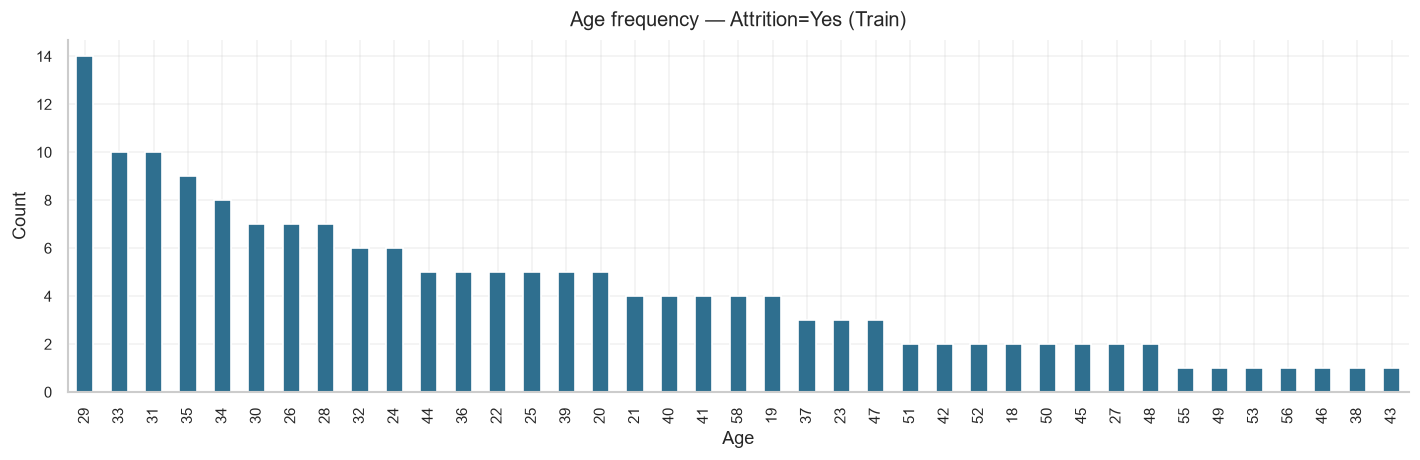

In [145]:
age_counts = attrition_yes["Age"].value_counts().sort_values(ascending=False)
plot_ranked_bars(
    age_counts,
    title="Age frequency — Attrition=Yes (Train)",
    xlabel="Age",
    ylabel="Count",
    color=PLOT_PRIMARY,
    figsize=(12, 4),
)

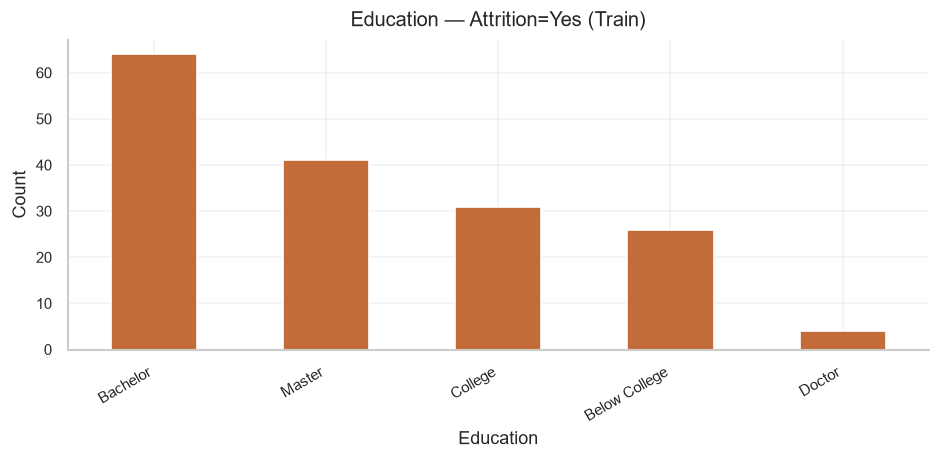

In [146]:
edu_counts = attrition_yes["Education"].value_counts().sort_values(ascending=False)
edu_counts.index = edu_counts.index.map(lambda x: EDUCATION_LABELS.get(int(x), str(x)))
plot_ranked_bars(
    edu_counts,
    title="Education — Attrition=Yes (Train)",
    xlabel="Education",
    ylabel="Count",
    color=PLOT_SECONDARY,
    figsize=(8, 4),
    rotate=30,
)

### 9.0.2 Conclusiones del EDA → transformaciones

Lo que me llevo del EDA:

1. Varias numéricas están sesgadas → `PowerTransformer` + escalado.
2. OverTime, JobRole, MaritalStatus y BusinessTravel marcan tasas de Attrition distintas → van al modelo (bien codificadas).
3. Education importa, pero como ordinal (etiquetas de Kaggle), no como nominal suelta.
4. Ingreso, antigüedad y distancia separan un poco Yes vs No → conviene alinear magnitudes.
5. Hay correlaciones altas entre features de tenure (años en empresa/rol/manager); L1/L2/EN ayudan con eso en Ej. 8–9.
6. Con ~16% Yes, accuracy sola no cuenta toda la historia, aunque sea la métrica de la actividad.

### 9.1 Costo de los errores (Ejercicio 6e)

Para IBM el costo no es simétrico:

- **FN:** predices que se queda y **sí se va**.  
  Duele más: se pierde talento sin chance de retener, hay reemplazo, curva de aprendizaje y desgaste en el equipo.
- **FP:** predices que se va y **se queda**.  
  Más barato si la alerta solo dispara un 1:1 o revisar carga; sube si el score se usa para estigmatizar.

En la práctica priorizaría bajar **FN**.  
La actividad mide accuracy, pero en un despliegue real miraría **recall de Yes** y/o movería el umbral (como se ve más adelante en la evaluación).

## 10.0 Ejercicio 7 — Pipeline + ColumnTransformer

Todo el preprocesamiento va en `Pipeline` + `ColumnTransformer` para:
- transformar por tipo de variable,
- no filtrar información (fit solo en train / dentro de cada fold),
- y poder reusar el mismo flujo en los modelos de después.

### 10.1 Diseño de transformaciones (justificación 7a–7e)

Con lo del EDA (skew, correlaciones, tasas de Attrition y perfiles Yes/No), armo estas familias de transformación:

In [147]:
numeric_pipeline: Pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("yeo_johnson", PowerTransformer(method="yeo-johnson")),
        ("scaler", MinMaxScaler()),
    ]
)

ordinal_pipeline: Pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", MinMaxScaler()),
    ]
)

binary_pipeline: Pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
        ),
    ]
)

nominal_pipeline: Pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

column_transformer: ColumnTransformer = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("ord", ordinal_pipeline, ORDINAL_FEATURES),
        ("bin", binary_pipeline, BINARY_FEATURES),
        ("nom", nominal_pipeline, NOMINAL_FEATURES),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

column_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer

In [148]:
preview_transformer = clone(column_transformer)
Xtrain_transformed = preview_transformer.fit_transform(Xtrain)
print("Transformed Train shape:", Xtrain_transformed.shape)
print("Output feature count:", len(preview_transformer.get_feature_names_out()))

Transformed Train shape: (1029, 49)
Output feature count: 49


In [149]:
numericas_pipeline = numeric_pipeline
numericas_pipeline_nombres = NUMERIC_FEATURES

In [150]:
catOrd_pipeline = ordinal_pipeline
catOrd_pipeline_nombres = ORDINAL_FEATURES

In [151]:
catBin_pipeline = binary_pipeline
catBin_pipeline_nombres = BINARY_FEATURES

In [152]:
catNom_pipeline = nominal_pipeline
catNom_pipeline_nombres = NOMINAL_FEATURES

In [153]:
columnasTransformer = column_transformer

### 10.2 Justificación detallada por tipo

**7a) Datos faltantes (`SimpleImputer`)**  
Este dataset casi siempre viene completo, pero meto imputación por si mañana llega un nulo y el pipeline no truene:
- numéricas → `strategy="median"` (más estable que la media con outliers),
- ordinales / binarias / nominales → `strategy="most_frequent"`.

**7b) Numéricas**  
- `PowerTransformer(yeo-johnson)`: en el EDA se ve sesgo en `MonthlyIncome`, `YearsAtCompany`, `TotalWorkingYears`, `DistanceFromHome`, etc. Yeo–Johnson aplana un poco la distribución y admite ≥ 0 (también negativos si hubiera).
- `MinMaxScaler`: deja magnitudes comparables; ayuda a KNN (distancia) y estabiliza la logística.

**7c) Ordinales**  
Ya vienen como enteros con orden (Education 1–5, satisfacciones 1–4, etc.).  
One-Hot aquí borraría ese orden. Imputo y escalo con `MinMaxScaler` para no romper la monotonía y alinear escalas con el resto.

**7d) Binarias (`Gender`, `OverTime`)**  
`OrdinalEncoder` a 0/1: dos niveles, sin un orden semántico raro que justifique one-hot.  
`handle_unknown="use_encoded_value"` por si aparece una categoría nueva.

**7e) Nominales**  
`BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus` no tienen orden natural.  
`OneHotEncoder(handle_unknown="ignore")` arma indicadores sin inventar jerarquías y tolera niveles nuevos en inferencia.

`ColumnTransformer` aplica cada pipeline a su lista (`NUMERIC_FEATURES`, `ORDINAL_FEATURES`, `BINARY_FEATURES`, `NOMINAL_FEATURES`) y tira lo demás (`remainder="drop"`).

## 11.0 Reagrupar Train + Val para validación cruzada

Test se guarda para el final. Sigo los nombres del enunciado: `Xtv`, `ytv`.

In [154]:
Xtv = pd.concat([Xtrain, Xval], axis=0)
ytv = pd.concat([ytrainT, yvalT], axis=0)

print("Train+Val shapes:", Xtv.shape, ytv.shape)
assert Xtv.shape[0] == ytv.shape[0]

Train+Val shapes: (1249, 30) (1249, 1)


## 12.0 Ejercicio 8 — modelos e hiperparámetros

`random_state=1` en los estimadores. Métrica: accuracy. Meta: pasar el baseline ≈ 0.839.

In [155]:
def build_models() -> tuple[list[object], list[str]]:
    models: list[object] = []
    names: list[str] = []
    
    models.append(
        LogisticRegression(
            penalty=None,
            solver="lbfgs",
            max_iter=5000,
            random_state=RANDOM_STATE_MODEL,
        )
    )
    names.append("LR")

    models.append(
        LogisticRegression(
            penalty="l1",
            solver="saga",
            C=1.0,
            max_iter=5000,
            random_state=RANDOM_STATE_MODEL,
        )
    )
    names.append("LASSO")

    models.append(
        LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            C=1.0,
            max_iter=5000,
            random_state=RANDOM_STATE_MODEL,
        )
    )
    names.append("RIDGE")

    models.append(
        LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=1.0,
            l1_ratio=0.5,
            max_iter=5000,
            random_state=RANDOM_STATE_MODEL,
        )
    )
    names.append("EN")

    models.append(
        KNeighborsClassifier(
            n_neighbors=7,
            weights="distance",
            metric="minkowski",
            p=2,
        )
    )
    names.append("KNN")

    return models, names

In [156]:
models, names = build_models()
cv_scores: list[np.ndarray] = []
y_tv = np.ravel(ytv)

In [157]:
cv1 = RepeatedStratifiedKFold(
    n_splits=CV_CFG.n_splits,
    n_repeats=CV_CFG.n_repeats,
    random_state=CV_CFG.random_state,
)

In [158]:
for model, name in zip(models, names, strict=True):
    pipe = Pipeline(steps=[("ct", column_transformer), ("m", model)])
    scores = cross_val_score(
        pipe,
        Xtv,
        y_tv,
        scoring=CV_CFG.scoring,
        cv=cv1,
        n_jobs=-1,
    )
    cv_scores.append(scores)
    print(f">> {name} {scores.mean():.3f} ({scores.std():.3f})")

cv_summary = pd.DataFrame(
    {
        "model": names,
        "mean_accuracy": [s.mean() for s in cv_scores],
        "std_accuracy": [s.std() for s in cv_scores],
        "beats_baseline": [s.mean() > BASELINE_ACCURACY for s in cv_scores],
    }
).sort_values("mean_accuracy", ascending=False)

>> LR 0.885 (0.014)
>> LASSO 0.887 (0.012)
>> RIDGE 0.888 (0.013)
>> EN 0.888 (0.014)
>> KNN 0.852 (0.010)


In [159]:
display(cv_summary)

,model,mean_accuracy,std_accuracy,beats_baseline
2,RIDGE,0.888,0.013,True
3,EN,0.888,0.014,True
1,LASSO,0.887,0.012,True
0,LR,0.885,0.014,True
4,KNN,0.852,0.010,True


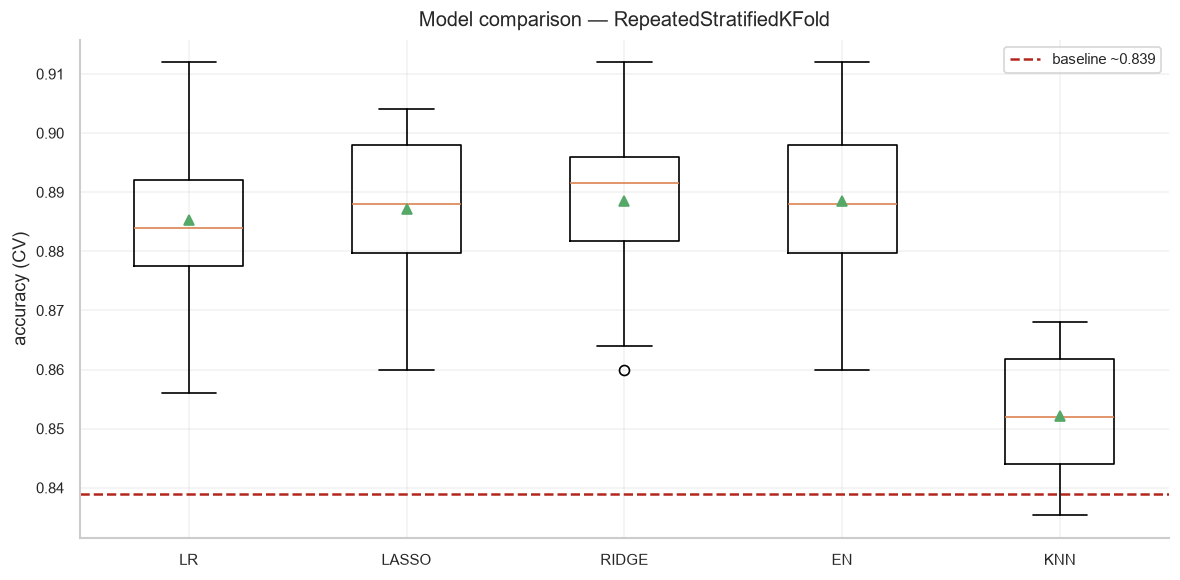

In [160]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_scores, tick_labels=names, showmeans=True)
ax.axhline(
    BASELINE_ACCURACY,
    color=PLOT_BASELINE,
    linestyle="--",
    label=f"baseline ~{BASELINE_ACCURACY:.3f}",
)

style_axes(ax, "Model comparison — RepeatedStratifiedKFold", ylabel="accuracy (CV)")
ax.legend()

finalize_figure()

### 12.1 Comentarios (Ejercicio 8b)

Con **accuracy** y `RepeatedStratifiedKFold` (5 splits × 3 repeats):

| Modelo | Accuracy media | Std | ¿Pasa baseline ≈0.839? |
|---|---:|---:|:---:|
| LR (`penalty=None`) | ~0.885 | ~0.014 | Sí |
| LASSO (L1) | ~0.887 | ~0.012 | Sí |
| **RIDGE (L2)** | **~0.888** | ~0.013 | Sí |
| EN (L1+L2) | ~0.888 | ~0.014 | Sí |
| KNN | ~0.852 | ~0.010 | Sí (más flojo) |

Me quedo con **RIDGE**: empata con EN en media y es más simple (solo L2).  
Ninguno queda debajo del baseline; el más cerca es KNN.  
En corto: con el preprocesamiento, un modelo lineal ya supera al ingenuo; KNN se complica más con el one-hot y el desbalance.  
Sigo al Ejercicio 9 afinando RIDGE con malla.

## 13.0 Ejercicio 9 — búsqueda de malla sobre el mejor modelo

Mantengo el nombre del enunciado: `resultado_malla`. Criterio de sobreajuste: gap train−val **< 3%**.

In [161]:
best_estimator = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=5000,
    random_state=RANDOM_STATE_MODEL,
)

best_pipe = Pipeline(
    steps=[
        ("ct", column_transformer),
        ("m", best_estimator),
    ]
)

param_grid: dict[str, list[float]] = {
    "m__C": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0],
}

grid_cv = RepeatedStratifiedKFold(
    n_splits=CV_CFG.n_splits,
    n_repeats=CV_CFG.n_repeats,
    random_state=CV_CFG.random_state,
)

resultado_malla: GridSearchCV = GridSearchCV(
    estimator=best_pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=grid_cv,
    return_train_score=True,
    n_jobs=-1,
    refit=True,
)

resultado_malla.fit(Xtv, np.ravel(ytv))

c:\Users\carlo\miniforge3\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'m__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",RepeatedStrat...andom_state=7)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscore

In [162]:
print("Best model performance (Accuracy)")
print("-" * 65)
print(
    "Best score: %f using hyperparameters %s"
    % (resultado_malla.best_score_, resultado_malla.best_params_)
)
print(
    "Train mean(std): %.2f%% (%.4f%%)"
    % (
        100 * np.nanmean(resultado_malla.cv_results_["mean_train_score"]),
        100 * np.nanmean(resultado_malla.cv_results_["std_train_score"]),
    )
)
print(
    "Val mean(std): %.2f%% (%.4f%%)"
    % (
        100 * resultado_malla.cv_results_["mean_test_score"].mean(),
        100 * resultado_malla.cv_results_["std_test_score"].mean(),
    )
)

Best model performance (Accuracy)
-----------------------------------------------------------------
Best score: 0.888441 using hyperparameters {'m__C': 1.0}
Train mean(std): 89.26% (0.4092%)
Val mean(std): 87.89% (1.1900%)


In [163]:
gap: float = float(
    np.nanmean(resultado_malla.cv_results_["mean_train_score"])
    - np.nanmean(resultado_malla.cv_results_["mean_test_score"])
)
print(f"Train-val gap: {gap:.4f}  (limit {OVERFIT_GAP_MAX})")
print("Overfitted?", "YES" if gap >= OVERFIT_GAP_MAX else "NO")
print(
    "Underfitted vs baseline?",
    "YES" if resultado_malla.best_score_ <= BASELINE_ACCURACY else "NO",
)

Train-val gap: 0.0137  (limit 0.03)
Overfitted? NO
Underfitted vs baseline? NO


## 14.0 Ejercicio 10 — evaluación final en Test

In [164]:
best_model = resultado_malla.best_estimator_

In [165]:
y_true = np.ravel(ytestT)
y_pred = best_model.predict(Xtest)
y_proba = best_model.predict_proba(Xtest)[:, 1]

In [166]:
print(classification_report(y_true, y_pred, target_names=["No", "Yes"]))

              precision    recall  f1-score   support

          No       0.89      0.97      0.93       185
         Yes       0.68      0.36      0.47        36

    accuracy                           0.87       221
   macro avg       0.79      0.66      0.70       221
weighted avg       0.85      0.87      0.85       221



### 14.0.1 Análisis adicional en Test

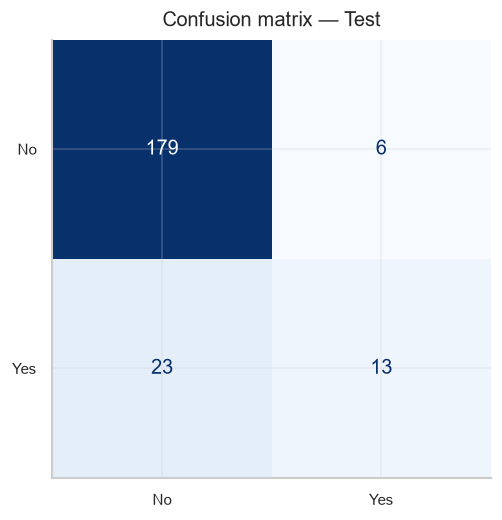

In [167]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["No", "Yes"],
    cmap=PLOT_CMAP,
    ax=ax,
    colorbar=False,
)

style_axes(ax, "Confusion matrix — Test")
finalize_figure()

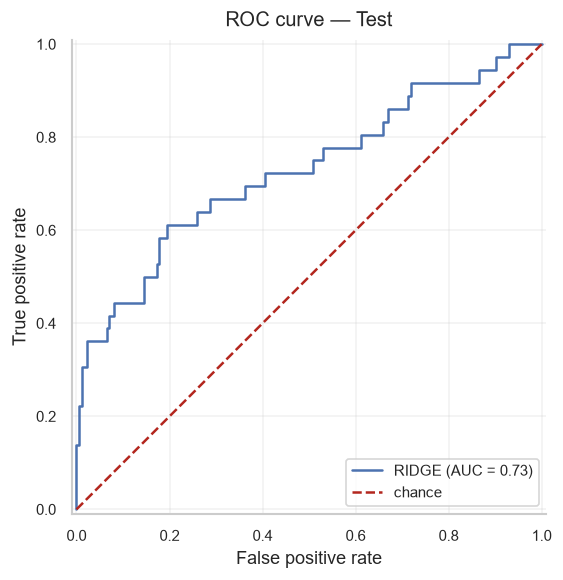

In [168]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_true, y_proba, ax=ax, name="RIDGE")
ax.plot([0, 1], [0, 1], linestyle="--", color=PLOT_BASELINE, label="chance")
style_axes(ax, "ROC curve — Test", "False positive rate", "True positive rate")
ax.legend(loc="lower right")

finalize_figure()

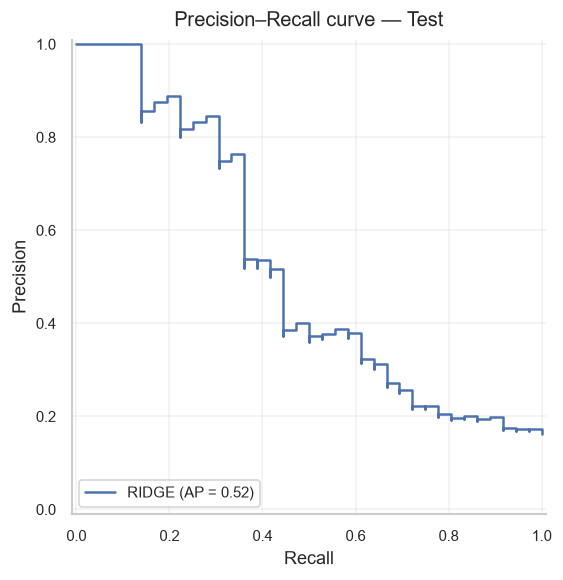

In [169]:
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_true, y_proba, ax=ax, name="RIDGE")

style_axes(ax, "Precision–Recall curve — Test", "Recall", "Precision")
finalize_figure()

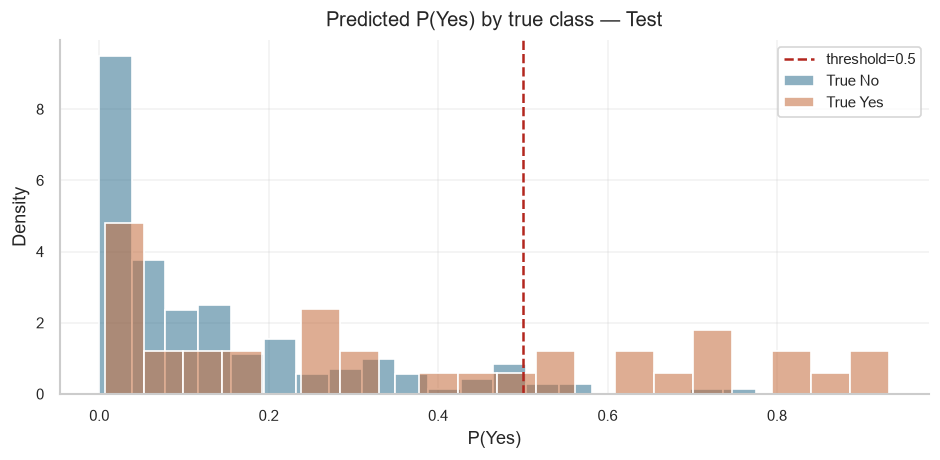

In [170]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    x=y_proba[y_true == 0],
    ax=ax,
    bins=20,
    color=PLOT_PRIMARY,
    label="True No",
    stat="density",
    alpha=0.55,
)

sns.histplot(
    x=y_proba[y_true == 1],
    ax=ax,
    bins=20,
    color=PLOT_SECONDARY,
    label="True Yes",
    stat="density",
    alpha=0.55,
)

ax.axvline(0.5, color=PLOT_BASELINE, linestyle="--", label="threshold=0.5")
style_axes(ax, "Predicted P(Yes) by true class — Test", "P(Yes)", "Density")
ax.legend()

finalize_figure()

In [171]:
thresholds = np.linspace(0.05, 0.95, 19)
rows = []

for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    tp = int(((pred_t == 1) & (y_true == 1)).sum())
    fp = int(((pred_t == 1) & (y_true == 0)).sum())
    fn = int(((pred_t == 0) & (y_true == 1)).sum())
    tn = int(((pred_t == 0) & (y_true == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    acc = (tp + tn) / len(y_true)

    rows.append({"threshold": t, "accuracy": acc, "precision_yes": prec, "recall_yes": rec})

threshold_df = pd.DataFrame(rows)

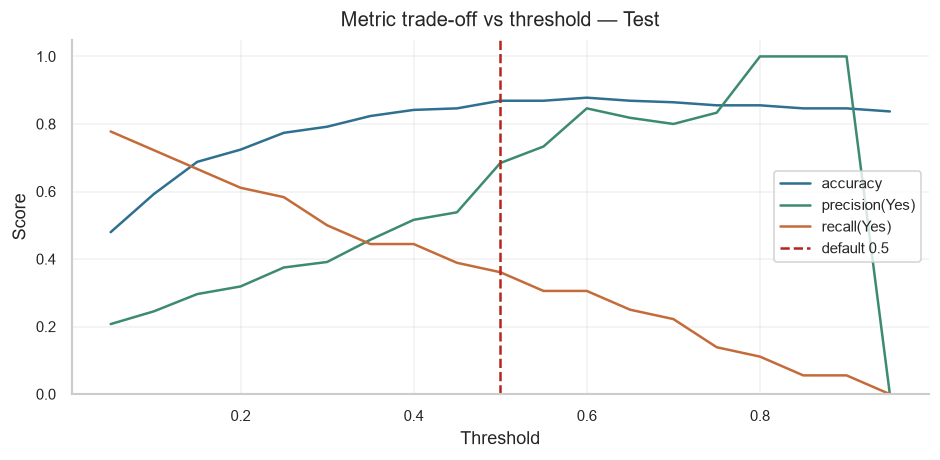

In [172]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(threshold_df["threshold"], threshold_df["accuracy"], label="accuracy", color=PLOT_PRIMARY)
ax.plot(threshold_df["threshold"], threshold_df["precision_yes"], label="precision(Yes)", color=PLOT_ACCENT)
ax.plot(threshold_df["threshold"], threshold_df["recall_yes"], label="recall(Yes)", color=PLOT_SECONDARY)
ax.axvline(0.5, color=PLOT_BASELINE, linestyle="--", label="default 0.5")

style_axes(ax, "Metric trade-off vs threshold — Test", "Threshold", "Score")
ax.set_ylim(0, 1.05)
ax.legend()

finalize_figure()

In [173]:
threshold_df.round(3)

,threshold,accuracy,precision_yes,recall_yes
0,0.050,0.480,0.207,0.778
1,0.100,0.593,0.245,0.722
2,0.150,0.688,0.296,0.667
3,0.200,0.724,0.319,0.611
4,0.250,0.774,0.375,0.583
5,0.300,0.792,0.391,0.500
6,0.350,0.824,0.457,0.444
7,0.400,0.842,0.516,0.444
8,0.450,0.846,0.538,0.389
9,0.500,0.869,0.684,0.361


### 14.1 Interpretación de VP / VN / FP / FN (Ejercicio 10c)

- **VP (TP):** predice **Yes** y sí se va → acierto; da chance de retener.
- **VN (TN):** predice **No** y se queda → bien clasificado; no gastas intervención de más.
- **FP:** predice **Yes** y se queda → falsa alarma; costo de RH y riesgo si se malinterpreta.
- **FN:** predice **No** y sí se va → no lo viste venir; suele ser el error más caro en operación.

In [174]:
feature_names = best_model.named_steps["ct"].get_feature_names_out()
coefs = np.ravel(best_model.named_steps["m"].coef_)

In [175]:
importance = (
    pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    .assign(abs_coef=lambda d: d["coefficient"].abs())
    .sort_values("abs_coef", ascending=False)
)

In [176]:
top_n = 15
top_imp = importance.head(top_n).iloc[::-1]
bar_colors = np.where(top_imp["coefficient"] > 0, PLOT_SECONDARY, PLOT_PRIMARY)

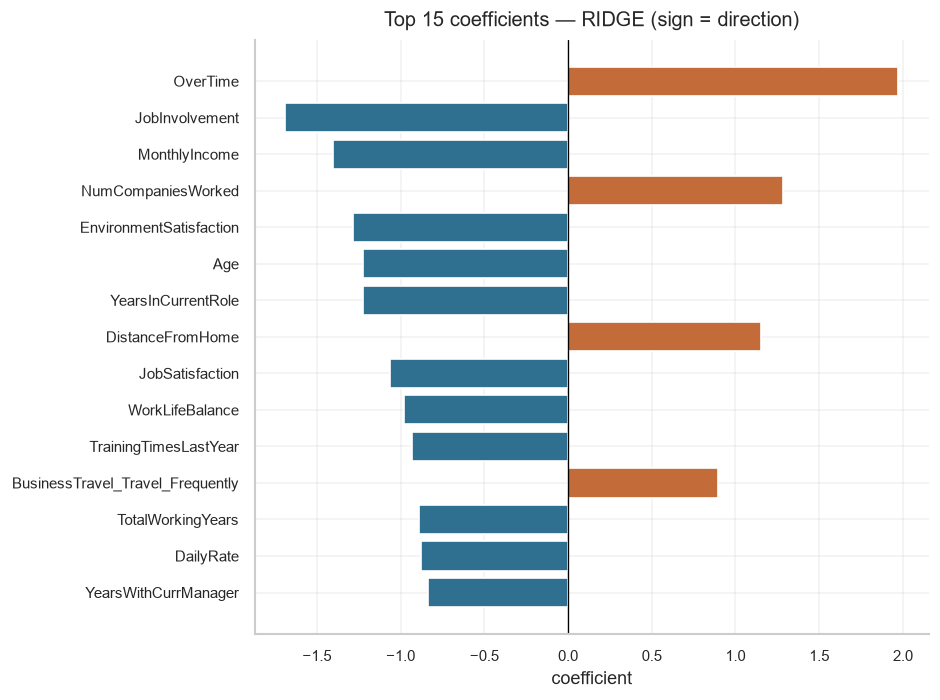

In [177]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_imp["feature"], top_imp["coefficient"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)

style_axes(
    ax,
    f"Top {top_n} coefficients — RIDGE (sign = direction)",
    xlabel="coefficient",
)

finalize_figure()

In [178]:
importance.head(top_n)

,feature,coefficient,abs_coef
24,OverTime,1.971,1.971
16,JobInvolvement,-1.688,1.688
6,MonthlyIncome,-1.403,1.403
0,NumCompaniesWorked,1.284,1.284
15,EnvironmentSatisfaction,-1.282,1.282
2,Age,-1.224,1.224
11,YearsInCurrentRole,-1.223,1.223
4,DistanceFromHome,1.154,1.154
18,JobSatisfaction,-1.065,1.065
22,WorkLifeBalance,-0.977,0.977


### 14.2 Comentarios sobre importancia de factores (Ejercicio 10d)

Los coeficientes de RIDGE (en valor absoluto) dicen cuánto empuja cada feature transformada al log-odds de Attrition:

- **Positivo** → hacia **Yes** (más riesgo de irse).
- **Negativo** → hacia **No** (más chance de quedarse).

Para negocio, me enfoco en variables **accionables** (OverTime, satisfacción/ambiente, rol, sueldo/antigüedad).  
Para ética: si Age, Gender o MaritalStatus aparecen arriba, no las uso como palanca adversa (ver Ejercicio 3); el score es para apoyo, no para discriminar.  
Ojo: esto es importancia en el espacio ya transformado (one-hot, scaling); features de tenure correlacionadas pueden repartirse el peso entre sí.

## 15.0 Ejercicio 11 — implicaciones y cierre

**a) Uso ético de predicciones con alta exactitud**  
Usaría los scores para retención proactiva y voluntaria: revisar carga, carrera, clima o compensación. No para vigilar, etiquetar ni sancionar. Acceso limitado, propósito documentado, alguien humano en el loop, y sin actuar solo sobre Age/Gender/MaritalStatus.

**b) ¿Qué error trata el modelo como más costoso?**  
El umbral 0.5 y la métrica accuracy **no** dicen explícitamente si FN o FP duele más. Hay que mirar la matriz en Test: si hay muchos FN / recall bajo en Yes, el modelo está dejando pasar fugas — y eso **no cuadra** con lo del Ejercicio 6e (FN más caro). Para alinear costos, hay que mover el umbral o usar métricas que penalicen ese error.

**c) Comunicación a un público no técnico**  
“Armamos un modelo que señala a colaboradores con más probabilidad de dejar la empresa. En datos que no vio durante el entrenamiento llega cerca de 87% de exactitud. Se puede equivocar de dos formas: alertar de más, o no detectar una salida. La idea es usar el score para platicar a tiempo y ofrecer apoyo — nunca como etiqueta negativa — y medir si eso realmente baja la rotación.”

**d) ¿Dónde ayudó más el LLM?**  
Sobre todo en armar la estructura del notebook, tipar columnas y revisar que los pipelines no filtraran información. También en bocetos de las respuestas éticas y de comunicación. Usé Cursor para checar el código. Yo reescribí la redacción, corrí todo y validé que los números cuadraran.

**e) Conclusiones finales**  
- Sí se puede predecir por encima del baseline de clase mayoritaria, pero con el desbalance el recall/F1 de Yes importan más de lo que sugiere la accuracy.  
- Los pipelines mantienen el preprocesamiento limpio (sin leakage) y repetible.  
- El valor real está en intervenir bien — ético y accionable — no en el score solo.  
- Siguiente paso natural: calibrar el umbral según FN/FP y revisar fairness.

## Referencias

IBM. (s. f.). *HR Analytics Employee Attrition & Performance* [Conjunto de datos]. Kaggle. https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://scikit-learn.org/

Anthropic. (2026). *Claude* [Modelo de lenguaje grande]. https://claude.ai/

Anysphere. (2026). *Cursor* [Entorno de desarrollo con IA]. https://cursor.com/
